In [1]:
import numpy as np
import torch
import torch.nn as nn
import json
import pickle
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
import pandas as pd
from tqdm import tqdm

# Configure plotting
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['svg.fonttype'] = 'none'


import os
os.chdir('src')

# Import custom modules
from models.mr_gnode import MRgnODE_DynamicComm
from utils import compute_r2

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set seeds
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: cuda


In [2]:
# Configuration
cache_path = Path("cache/ibl_multiregion")
config_file = "configs/ibl_multiregion.json"  # Update path as needed

# Load config
with open(config_file, 'r') as f:
    config = json.load(f)

print("Loading trained model and data...")
print(f"Session: {config['ibl_params']['eid']}")
print(f"Regions: {list(config['region_mapping'].keys())}")

# Load cached data
data_file = cache_path / 'ibl_processed_data.pkl'
with open(data_file, 'rb') as f:
    cached_data = pickle.load(f)

# Extract data splits
train_data = cached_data['processed_data']['train']
val_data = cached_data['processed_data']['val']
test_data = cached_data['processed_data']['test']

# Load model
model_params = config['model_params']
model_params['num_regions'] = len(config['region_mapping'])

model = MRgnODE_DynamicComm(**model_params).to(device)
model.load_state_dict(torch.load(cache_path / 'model.pt', map_location=device))
model.eval()

# Load metadata
with open(cache_path / 'metadata.json', 'r') as f:
    metadata = json.load(f)

print(f"\n✓ Model loaded successfully")
print(f"  Training R²: {metadata['final_r2']:.3f}")
print(f"  Validation R²: {metadata['val_r2']:.3f}")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading trained model and data...
Session: 113c5b6c-940e-4b21-b462-789b4c2be0e5
Regions: ['region_1', 'region_2']

✓ Model loaded successfully
  Training R²: 0.517
  Validation R²: 0.497
  Total parameters: 39,570


Data Shapes:

Train:
  region_1: (295, 10, 162)
  region_2: (295, 10, 46)

Val:
  region_1: (63, 10, 162)
  region_2: (63, 10, 46)

Test:
  region_1: (63, 10, 162)
  region_2: (63, 10, 46)

Neuron-to-Region Mapping:
  region_1: 162 neurons from ['MOp']
  region_2: 46 neurons from ['MOs']

Computing test metrics...
Test MSE: 0.1139
Test R²: 0.499


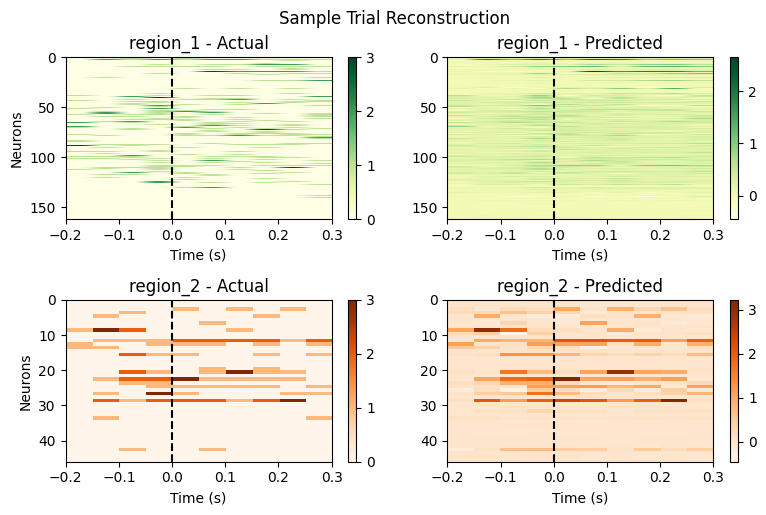

In [3]:
# Display data shapes
print("Data Shapes:")
for name, data in [('Train', train_data), ('Val', val_data), ('Test', test_data)]:
    print(f"\n{name}:")
    for key in ['region_1', 'region_2']:
        if key in data: print(f"  {key}: {data[key].shape}")

# Neuron assignments
print("\nNeuron-to-Region Mapping:")
for region, info in cached_data.get('neuron_assignments', {}).items():
    if "_meta" not in region:
        print(f"  {region}: {info['n_neurons']} neurons from {info['brain_areas']}")

# Test metrics
print("\nComputing test metrics...")
test_regions = {k: v for k, v in test_data.items() if k.startswith('region_')}
with torch.no_grad():
    test_preds = model.predict(test_regions)
    
    test_preds_concat = np.concatenate(list(test_preds.values()), axis=-1) if isinstance(test_preds, dict) else test_preds
    test_targets_concat = np.concatenate(list(test_regions.values()), axis=-1)
    
    test_mse = np.mean((test_preds_concat - test_targets_concat) ** 2)
    test_r2 = compute_r2(test_preds_concat.flatten(), test_targets_concat.flatten())
print(f"Test MSE: {test_mse:.4f}\nTest R²: {test_r2:.3f}")

# Visualization
psth_fig, axes = plt.subplots(2, 2, figsize=(8, 5))
trial_idx = 0
time_extent = [-0.2, 0.3, 0, 1]  # [left, right, bottom, top] for extent

for i, (region, cmap) in enumerate(zip(['region_1', 'region_2'], ['YlGn', 'Oranges'])):
    # Actual
    im = axes[i, 0].imshow(test_regions[region][trial_idx].T, aspect='auto', cmap=cmap, 
                           extent=[-0.2, 0.3, test_regions[region].shape[2], 0])
    axes[i, 0].set_title(f'{region} - Actual')
    axes[i, 0].set_xlabel('Time (s)')
    axes[i, 0].set_ylabel('Neurons')
    axes[i, 0].axvline(0, label='movement onset', linestyle='--', color='black')

    plt.colorbar(im, ax=axes[i, 0])
    
    # Predicted
    if isinstance(test_preds, dict):
        pred_data = test_preds[region][trial_idx].T
    else:
        start = i * model_params['output_dims'][i]
        pred_data = test_preds[trial_idx, :, start:start+model_params['output_dims'][i]].T
    
    im = axes[i, 1].imshow(pred_data, aspect='auto', cmap=cmap,
                           extent=[-0.2, 0.3, pred_data.shape[0], 0])
    axes[i, 1].set_title(f'{region} - Predicted')
    axes[i, 1].set_xlabel('Time (s)')
    axes[i, 1].axvline(0, label='movement onset', linestyle='--', color='black')

    plt.colorbar(im, ax=axes[i, 1])

plt.tight_layout()
plt.suptitle('Sample Trial Reconstruction', y=1.02)
plt.show()
psth_fig.savefig("plots/fig3_psth_a.svg")

Extracting communication dynamics...


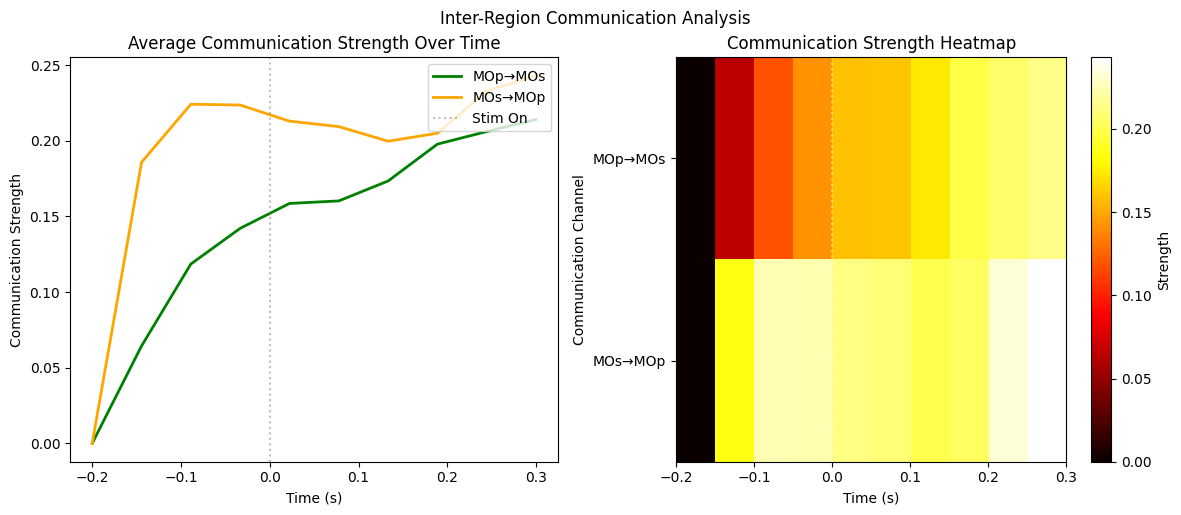


Communication Statistics:
  MOp→MOs: Mean=0.143, Max=0.214, Peak at 0.300s
  MOs→MOp: Mean=0.194, Max=0.243, Peak at 0.300s

Communication Asymmetry (MOp→MOs - MOs→MOp):
  Mean asymmetry: -0.050
  Max asymmetry: 0.000 at -0.200s
  Min asymmetry: -0.121 at -0.144s


In [4]:
def extract_communication_dynamics(model, data, n_samples=10):
    """Extract communication channel activities during forward pass"""
    device = next(model.parameters()).device
    dt = 0.01
    
    # Prepare data
    regions = {k: v for k, v in data.items() if k.startswith('region_')}
    region_list = [regions[f'region_{i+1}'] for i in range(len(regions))]
    
    # Sample trials
    n_trials = region_list[0].shape[0]
    sample_indices = np.random.choice(n_trials, min(n_samples, n_trials), replace=False)
    
    comm_activities = []
    region_activities = []
    
    for idx in sample_indices:
        # Get trial data
        trial_data = [torch.tensor(r[idx:idx+1], dtype=torch.float32).to(device) 
                     for r in region_list]
        
        seq_len = trial_data[0].shape[1]
        max_input_dim = max(model.input_dims)
        
        # Pad inputs
        padded_inputs = []
        for i, td in enumerate(trial_data):
            if td.shape[-1] < max_input_dim:
                padding = torch.zeros(1, seq_len, max_input_dim - td.shape[-1], device=device)
                padded = torch.cat([td, padding], dim=-1)
            else:
                padded = td[..., :max_input_dim]
            padded_inputs.append(padded)
        
        batch_input = torch.stack(padded_inputs, dim=2).squeeze(0)
        
        # Initialize state
        h = torch.zeros(1, model.N_total, device=device)
        if model.hidden_state_init == 'xavier':
            nn.init.xavier_uniform_(h)
        
        trial_comm = []
        trial_regions = []
        
        # Forward pass
        for t in range(seq_len):
            h_regions, h_comm = model.partition_state(h)
            
            # Store activities
            trial_comm.append(h_comm.detach().cpu().numpy())
            trial_regions.append([hr.detach().cpu().numpy() for hr in h_regions])
            
            # Update state
            h_dot, _ = model(h, batch_input[t:t+1], timestep=t)
            h = h + dt * h_dot
        
        comm_activities.append(np.array(trial_comm))
        region_activities.append(trial_regions)
    
    return comm_activities, region_activities, sample_indices

# Extract communication dynamics
print("Extracting communication dynamics...")
comm_acts, region_acts, sample_ids = extract_communication_dynamics(model, test_data, n_samples=20)

# Analyze communication patterns
comm_strengths = []
for trial_comm in comm_acts:
    trial_strength = np.linalg.norm(trial_comm.squeeze(1), axis=-1)
    comm_strengths.append(trial_strength)

comm_strengths = np.array(comm_strengths)
mean_comm = comm_strengths.mean(axis=0)
time_points = np.linspace(-0.2, 0.3, mean_comm.shape[0])

# Channel names and colors
channel_names = ['MOp→MOs', 'MOs→MOp']
channel_colors = ['green', 'orange']

# Visualization
comm_fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Average communication strength over time
ax = axes[0]
for i, (name, color) in enumerate(zip(channel_names, channel_colors)):
    ax.plot(time_points, mean_comm[:, i], label=name, color=color, linewidth=2)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Communication Strength')
ax.set_title('Average Communication Strength Over Time')
ax.axvline(0, color='gray', linestyle=':', alpha=0.5, label='Stim On')
ax.legend(loc='upper right')

# Communication strength heatmap
ax = axes[1]
im = ax.imshow(mean_comm.T, aspect='auto', cmap='hot', interpolation='nearest',
               extent=[-0.2, 0.3, 2, 0])
ax.set_xlabel('Time (s)')
ax.set_ylabel('Communication Channel')
ax.set_yticks([0.5, 1.5])
ax.set_yticklabels(channel_names)
ax.set_title('Communication Strength Heatmap')
ax.axvline(0, color='white', linestyle=':', alpha=0.5)
plt.colorbar(im, ax=ax, label='Strength')

plt.tight_layout()
plt.suptitle('Inter-Region Communication Analysis', y=1.02, fontsize=12)
plt.show()

# Summary statistics
print("\nCommunication Statistics:")
for i, (name, color) in enumerate(zip(channel_names, channel_colors)):
    channel_mean = mean_comm[:, i].mean()
    channel_max = mean_comm[:, i].max()
    peak_time = time_points[mean_comm[:, i].argmax()]
    print(f"  {name}: Mean={channel_mean:.3f}, Max={channel_max:.3f}, Peak at {peak_time:.3f}s")

# Asymmetry analysis
asymmetry = mean_comm[:, 0] - mean_comm[:, 1]  # MOp→MOs minus MOs→MOp
print(f"\nCommunication Asymmetry (MOp→MOs - MOs→MOp):")
print(f"  Mean asymmetry: {asymmetry.mean():.3f}")
print(f"  Max asymmetry: {asymmetry.max():.3f} at {time_points[asymmetry.argmax()]:.3f}s")
print(f"  Min asymmetry: {asymmetry.min():.3f} at {time_points[asymmetry.argmin()]:.3f}s")
comm_fig.savefig('plots/fig3_comm_str_b.svg', bbox_inches='tight')

Extracting communication dynamics by choice type...


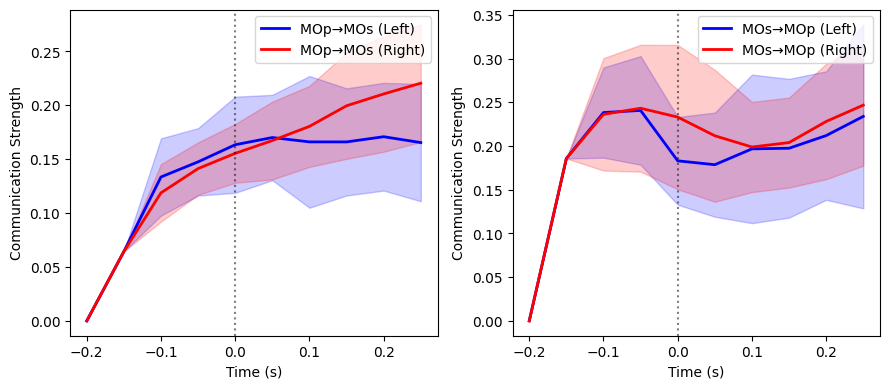


Communication Choice Selectivity:
Trials analyzed: 17 left, 46 right
  MOp→MOs:
    Mean R-L difference: 0.011
    Max |difference|: 0.055 at t=0.25s
    d-prime: 0.18
  MOs→MOp:
    Mean R-L difference: 0.012
    Max |difference|: 0.050 at t=0.00s
    d-prime: 0.02


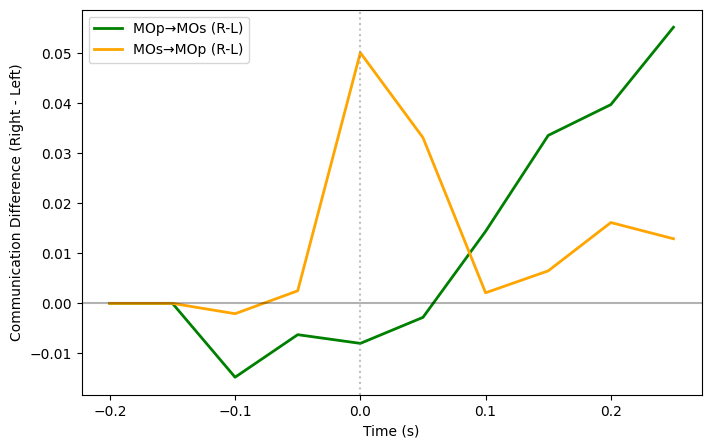

In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def extract_communication_by_choice(model, data, n_samples=None):
    """Extract communication dynamics split by choice type"""
    device = next(model.parameters()).device
    dt = 0.01
    
    # Get behavioral data
    choice = data['behavior']['choice']
    left_trials = np.where(choice == -1)[0]
    right_trials = np.where(choice == 1)[0]
    
    # Prepare neural data
    regions = {k: v for k, v in data.items() if k.startswith('region_')}
    region_list = [regions[f'region_{i+1}'] for i in range(len(regions))]
    
    # Sample trials if specified
    if n_samples:
        left_trials = np.random.choice(left_trials, min(n_samples, len(left_trials)), replace=False)
        right_trials = np.random.choice(right_trials, min(n_samples, len(right_trials)), replace=False)
    
    # Storage for each choice type
    comm_left = []
    comm_right = []
    
    # Process left trials
    for idx in left_trials:
        trial_data = [torch.tensor(r[idx:idx+1], dtype=torch.float32).to(device) 
                     for r in region_list]
        
        seq_len = trial_data[0].shape[1]
        max_input_dim = max(model.input_dims)
        
        # Pad inputs
        padded_inputs = []
        for i, td in enumerate(trial_data):
            if td.shape[-1] < max_input_dim:
                padding = torch.zeros(1, seq_len, max_input_dim - td.shape[-1], device=device)
                padded = torch.cat([td, padding], dim=-1)
            else:
                padded = td[..., :max_input_dim]
            padded_inputs.append(padded)
        
        batch_input = torch.stack(padded_inputs, dim=2).squeeze(0)
        
        # Initialize and run
        h = torch.zeros(1, model.N_total, device=device)
        if model.hidden_state_init == 'xavier':
            nn.init.xavier_uniform_(h)
        
        trial_comm = []
        for t in range(seq_len):
            h_regions, h_comm = model.partition_state(h)
            trial_comm.append(h_comm.detach().cpu().numpy())
            h_dot, _ = model(h, batch_input[t:t+1], timestep=t)
            h = h + dt * h_dot
        
        comm_left.append(np.array(trial_comm))
    
    # Process right trials
    for idx in right_trials:
        trial_data = [torch.tensor(r[idx:idx+1], dtype=torch.float32).to(device) 
                     for r in region_list]
        
        seq_len = trial_data[0].shape[1]
        max_input_dim = max(model.input_dims)
        
        # Pad inputs
        padded_inputs = []
        for i, td in enumerate(trial_data):
            if td.shape[-1] < max_input_dim:
                padding = torch.zeros(1, seq_len, max_input_dim - td.shape[-1], device=device)
                padded = torch.cat([td, padding], dim=-1)
            else:
                padded = td[..., :max_input_dim]
            padded_inputs.append(padded)
        
        batch_input = torch.stack(padded_inputs, dim=2).squeeze(0)
        
        # Initialize and run
        h = torch.zeros(1, model.N_total, device=device)
        if model.hidden_state_init == 'xavier':
            nn.init.xavier_uniform_(h)
        
        trial_comm = []
        for t in range(seq_len):
            h_regions, h_comm = model.partition_state(h)
            trial_comm.append(h_comm.detach().cpu().numpy())
            h_dot, _ = model(h, batch_input[t:t+1], timestep=t)
            h = h + dt * h_dot
        
        comm_right.append(np.array(trial_comm))
    
    return comm_left, comm_right, left_trials, right_trials

# Extract communication dynamics by choice
print("Extracting communication dynamics by choice type...")
comm_left, comm_right, left_ids, right_ids = extract_communication_by_choice(model, test_data, n_samples=50)

# Calculate mean communication strength for each channel
comm_left_strength = []
for trial in comm_left:
    # trial shape: [time, batch=1, n_channels, comm_dim]
    strength = np.linalg.norm(trial.squeeze(1), axis=-1)  # [time, n_channels]
    comm_left_strength.append(strength)

comm_right_strength = []
for trial in comm_right:
    strength = np.linalg.norm(trial.squeeze(1), axis=-1)  # [time, n_channels]
    comm_right_strength.append(strength)

# Average across trials
mean_left = np.mean(comm_left_strength, axis=0)  # [time, n_channels]
std_left = np.std(comm_left_strength, axis=0)
mean_right = np.mean(comm_right_strength, axis=0)
std_right = np.std(comm_right_strength, axis=0)

# Time axis
time_points = np.arange(mean_left.shape[0]) * config['ibl_params']['bin_size'] - config['ibl_params']['pre_time']

# Create figure with 2 regions (assuming 2 regions, 2 channels of communication)
choice_comm, axes = plt.subplots(1, 2, figsize=(9, 4))

# Channel mapping: For 2 regions, channels are [MOp→MOs, MOs→MOp]
channel_names = ['MOp→MOs', 'MOs→MOp']
channel_sources = []
for source in range(model.num_regions):
    for target in range(model.num_regions):
        if source != target:
            channel_sources.append(source)

# Plot for each source region
for region_idx in range(model.num_regions):
    ax = axes[region_idx]
    brain_area = config['region_mapping'][f'region_{region_idx+1}'][0]
    
    # Find channels originating from this region
    region_channels = [i for i, src in enumerate(channel_sources) if src == region_idx]
    
    for ch_idx in region_channels:
        # Plot left trials
        ax.plot(time_points, mean_left[:, ch_idx], 'b-', lw=2, 
                label=f'{channel_names[ch_idx]} (Left)')
        ax.fill_between(time_points, 
                        mean_left[:, ch_idx] - std_left[:, ch_idx],
                        mean_left[:, ch_idx] + std_left[:, ch_idx],
                        alpha=0.2, color='blue')
        
        # Plot right trials
        ax.plot(time_points, mean_right[:, ch_idx], 'r-', lw=2,
                label=f'{channel_names[ch_idx]} (Right)')
        ax.fill_between(time_points,
                        mean_right[:, ch_idx] - std_right[:, ch_idx],
                        mean_right[:, ch_idx] + std_right[:, ch_idx],
                        alpha=0.2, color='red')
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Communication Strength')
    ax.axvline(0, color='black', linestyle=':', alpha=0.5)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Compute choice selectivity in communication
print(f"\nCommunication Choice Selectivity:")
print(f"Trials analyzed: {len(left_ids)} left, {len(right_ids)} right")

for i, name in enumerate(channel_names):
    # Average difference across time
    diff = mean_right[:, i] - mean_left[:, i]
    avg_diff = np.mean(diff)
    max_diff = np.max(np.abs(diff))
    peak_time = time_points[np.argmax(np.abs(diff))]
    
    # d-prime for communication
    pooled_std = np.sqrt((std_left[:, i]**2 + std_right[:, i]**2) / 2)
    dprime = np.mean(diff / (pooled_std + 1e-8))
    
    print(f"  {name}:")
    print(f"    Mean R-L difference: {avg_diff:.3f}")
    print(f"    Max |difference|: {max_diff:.3f} at t={peak_time:.2f}s")
    print(f"    d-prime: {dprime:.2f}")

# Additional plot: Difference in communication
choice_comm2, ax = plt.subplots(1, 1, figsize=(8, 5))

colors = ['green','orange']
for i, name in enumerate(channel_names):
    diff = mean_right[:, i] - mean_left[:, i]
    ax.plot(time_points, diff, lw=2, label=f'{name} (R-L)', color=colors[i])

ax.axhline(0, color='black', linestyle='-', alpha=0.3)
ax.axvline(0, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Communication Difference (Right - Left)')
ax.legend()
plt.show()

choice_comm.savefig('plots/fig3_choice_time.svg')
choice_comm2.savefig('plots/fig3_choice_diff.svg')

SIMPLE JACOBIAN DIVERGENCE ANALYSIS
Computing Jacobian divergence across 10 timesteps...
  t=0 (-200ms): MOp→MOs=0.0°, MOs→MOp=0.0°
  t=1 (-150ms): MOp→MOs=1.6°, MOs→MOp=2.0°
  t=2 (-100ms): MOp→MOs=1.6°, MOs→MOp=2.9°
  t=3 (-50ms): MOp→MOs=2.4°, MOs→MOp=8.2°
  t=4 (0ms): MOp→MOs=2.6°, MOs→MOp=6.8°
  t=5 (50ms): MOp→MOs=2.3°, MOs→MOp=4.8°
  t=6 (100ms): MOp→MOs=2.4°, MOs→MOp=3.8°
  t=7 (150ms): MOp→MOs=4.1°, MOs→MOp=3.8°
  t=8 (200ms): MOp→MOs=3.7°, MOs→MOp=4.4°

JACOBIAN DIVERGENCE SUMMARY
Analyzed 17 left trials, 30 right trials
Time range: -200 to 200 ms

MOp→MOs (Feedback):
  Peak divergence: 4.1° ± 0.0°
  Peak time: 150 ms
  Mean divergence: 2.3° ± 0.1°

MOs→MOp (Feedforward):
  Peak divergence: 8.2° ± 0.9°
  Peak time: -50 ms
  Mean divergence: 4.1° ± 0.0°

→ MOs→MOp leads (feedforward), peaking 200ms earlier


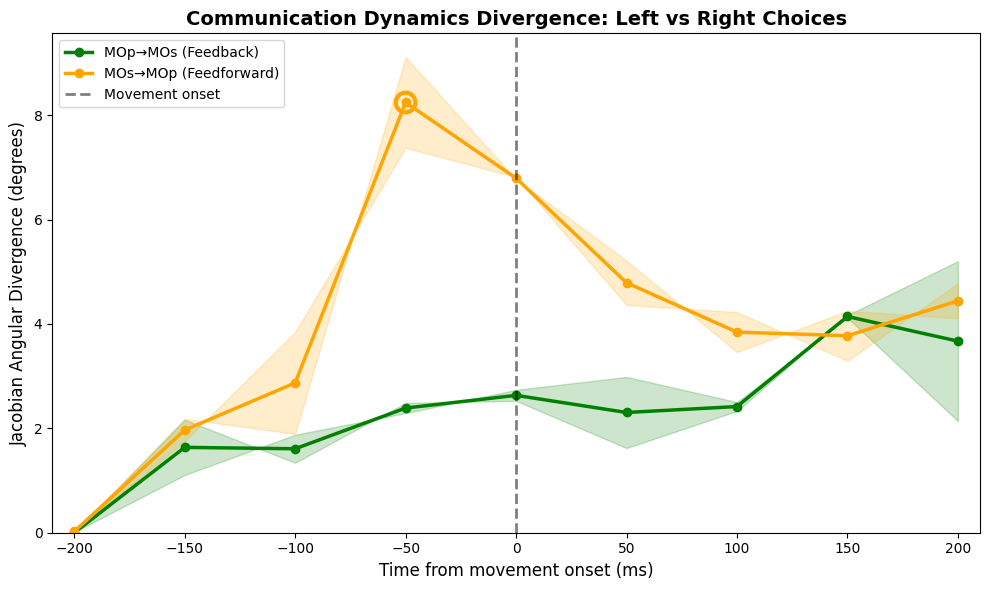

In [6]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def compute_comm_jacobian(model, h_state, x_input):
    """Compute Jacobian for communication channels only"""
    device = next(model.parameters()).device
    h_state = h_state.clone().detach().requires_grad_(True)
    
    # Forward pass
    h_dot, _ = model(h_state, x_input, timestep=0)
    
    # Extract communication part of h_dot
    comm_start = model.N_regions
    comm_end = comm_start + model.num_comm_channels * model.comm_dim
    
    # Compute Jacobian only for communication channels
    jacobian_r1r2 = []
    jacobian_r2r1 = []
    
    # MOp→MOs channel (first comm_dim dimensions)
    for i in range(model.comm_dim):
        grad_outputs = torch.zeros_like(h_dot)
        grad_outputs[0, comm_start + i] = 1.0
        grad = torch.autograd.grad(h_dot, h_state, grad_outputs=grad_outputs, 
                                   retain_graph=True, create_graph=False)[0]
        # Extract gradient w.r.t. communication states
        jacobian_r1r2.append(grad[0, comm_start:comm_start+model.comm_dim].detach().cpu().numpy())
    
    # MOs→MOp channel (next comm_dim dimensions)
    for i in range(model.comm_dim):
        grad_outputs = torch.zeros_like(h_dot)
        grad_outputs[0, comm_start + model.comm_dim + i] = 1.0
        grad = torch.autograd.grad(h_dot, h_state, grad_outputs=grad_outputs, 
                                   retain_graph=True, create_graph=False)[0]
        jacobian_r2r1.append(grad[0, comm_start+model.comm_dim:comm_start+2*model.comm_dim].detach().cpu().numpy())
    
    return np.array(jacobian_r1r2), np.array(jacobian_r2r1)

def simple_jacobian_divergence(model, data, config, n_samples=20):
    """
    Simple Jacobian-based divergence analysis
    """
    device = next(model.parameters()).device
    
    # Get timing info
    bin_size = config['ibl_params']['bin_size']
    pre_time = config['ibl_params']['pre_time']
    n_timesteps = data['region_1'].shape[1]
    
    # Create time axis
    time_ms = np.arange(n_timesteps-1) * bin_size * 1000 - pre_time * 1000
    
    print(f"Computing Jacobian divergence across {n_timesteps} timesteps...")
    
    # Get trials by choice
    choice = data['behavior']['choice']
    left_trials = np.where(choice == -1)[0][:n_samples]
    right_trials = np.where(choice == 1)[0][:n_samples]
    
    # Prepare data
    regions = {k: v for k, v in data.items() if k.startswith('region_')}
    region_list = [regions[f'region_{i+1}'] for i in range(len(regions))]
    
    # Store Jacobians for each timestep
    divergence_r1r2 = []
    divergence_r2r1 = []
    std_r1r2 = []
    std_r2r1 = []
    
    # Process each timestep
    for t in range(n_timesteps-1):
        left_jac_r1r2 = []
        left_jac_r2r1 = []
        right_jac_r1r2 = []
        right_jac_r2r1 = []
        
        # Process LEFT trials
        for idx in left_trials:
            trial_data = [torch.tensor(r[idx], dtype=torch.float32).to(device) 
                         for r in region_list]
            
            # Initialize and evolve state to time t
            h = torch.zeros(1, model.N_total, device=device)
            
            for tau in range(t + 1):
                # Prepare input
                max_input_dim = max(model.input_dims)
                padded_inputs = []
                for i, region_data in enumerate(trial_data):
                    tau_data = region_data[tau:tau+1]
                    if tau_data.shape[-1] < max_input_dim:
                        padding = torch.zeros(1, max_input_dim - tau_data.shape[-1], device=device)
                        padded = torch.cat([tau_data, padding], dim=-1)
                    else:
                        padded = tau_data[:, :max_input_dim]
                    padded_inputs.append(padded.unsqueeze(0))
                
                batch_input = torch.cat(padded_inputs, dim=1)
                
                if tau < t:
                    # Evolve state
                    h_dot, _ = model(h, batch_input, timestep=tau)
                    h = h + bin_size * h_dot
                else:
                    # Compute Jacobian at time t
                    jac_r1r2, jac_r2r1 = compute_comm_jacobian(model, h, batch_input)
                    left_jac_r1r2.append(jac_r1r2.flatten())
                    left_jac_r2r1.append(jac_r2r1.flatten())
        
        # Process RIGHT trials
        for idx in right_trials:
            trial_data = [torch.tensor(r[idx], dtype=torch.float32).to(device) 
                         for r in region_list]
            
            h = torch.zeros(1, model.N_total, device=device)
            
            for tau in range(t + 1):
                max_input_dim = max(model.input_dims)
                padded_inputs = []
                for i, region_data in enumerate(trial_data):
                    tau_data = region_data[tau:tau+1]
                    if tau_data.shape[-1] < max_input_dim:
                        padding = torch.zeros(1, max_input_dim - tau_data.shape[-1], device=device)
                        padded = torch.cat([tau_data, padding], dim=-1)
                    else:
                        padded = tau_data[:, :max_input_dim]
                    padded_inputs.append(padded.unsqueeze(0))
                
                batch_input = torch.cat(padded_inputs, dim=1)
                
                if tau < t:
                    h_dot, _ = model(h, batch_input, timestep=tau)
                    h = h + bin_size * h_dot
                else:
                    jac_r1r2, jac_r2r1 = compute_comm_jacobian(model, h, batch_input)
                    right_jac_r1r2.append(jac_r1r2.flatten())
                    right_jac_r2r1.append(jac_r2r1.flatten())
        
        # Compute mean Jacobians
        mean_left_r1r2 = np.mean(left_jac_r1r2, axis=0)
        mean_right_r1r2 = np.mean(right_jac_r1r2, axis=0)
        mean_left_r2r1 = np.mean(left_jac_r2r1, axis=0)
        mean_right_r2r1 = np.mean(right_jac_r2r1, axis=0)
        
        # Compute std of Jacobians across trials
        std_left_r1r2 = np.std(left_jac_r1r2, axis=0)
        std_right_r1r2 = np.std(right_jac_r1r2, axis=0)
        std_left_r2r1 = np.std(left_jac_r2r1, axis=0)
        std_right_r2r1 = np.std(right_jac_r2r1, axis=0)
        
        # Compute angular divergence
        def angle_between(v1, v2):
            cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
            cos_angle = np.clip(cos_angle, -1, 1)
            return np.arccos(cos_angle) * 180 / np.pi
        
        div_r1r2 = angle_between(mean_left_r1r2, mean_right_r1r2)
        div_r2r1 = angle_between(mean_left_r2r1, mean_right_r2r1)
        
        # Compute divergence with +/- 1 std for error estimation
        div_r1r2_upper = angle_between(mean_left_r1r2 + std_left_r1r2, mean_right_r1r2 - std_right_r1r2)
        div_r1r2_lower = angle_between(mean_left_r1r2 - std_left_r1r2, mean_right_r1r2 + std_right_r1r2)
        div_r2r1_upper = angle_between(mean_left_r2r1 + std_left_r2r1, mean_right_r2r1 - std_right_r2r1)
        div_r2r1_lower = angle_between(mean_left_r2r1 - std_left_r2r1, mean_right_r2r1 + std_right_r2r1)
        
        divergence_r1r2.append(div_r1r2)
        divergence_r2r1.append(div_r2r1)
        std_r1r2.append((div_r1r2_upper - div_r1r2_lower) / 2)
        std_r2r1.append((div_r2r1_upper - div_r2r1_lower) / 2)
        
        print(f"  t={t} ({time_ms[t]:.0f}ms): MOp→MOs={divergence_r1r2[-1]:.1f}°, MOs→MOp={divergence_r2r1[-1]:.1f}°")
    
    divergence_r1r2 = np.array(divergence_r1r2)
    divergence_r2r1 = np.array(divergence_r2r1)
    std_r1r2 = np.array(std_r1r2)
    std_r2r1 = np.array(std_r2r1)
    
    # Determine which is feedforward (peaks earlier)
    peak_time_r1r2 = time_ms[np.argmax(divergence_r1r2)]
    peak_time_r2r1 = time_ms[np.argmax(divergence_r2r1)]
    
    if peak_time_r1r2 < peak_time_r2r1:
        labels = ['MOp→MOs (Feedforward)', 'MOs→MOp (Feedback)']
    else:
        labels = ['MOp→MOs (Feedback)', 'MOs→MOp (Feedforward)']
    
    # Create single clean plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Plot divergence with std bands for each channel
    ax.plot(time_ms, divergence_r1r2, 
            color='green', linewidth=2.5, 
            label=labels[0], marker='o', markersize=6)
    ax.fill_between(time_ms, 
                    divergence_r1r2 - std_r1r2,
                    divergence_r1r2 + std_r1r2,
                    alpha=0.2, color='green')
    
    ax.plot(time_ms, divergence_r2r1, 
            color='orange', linewidth=2.5, 
            label=labels[1], marker='o', markersize=6)
    ax.fill_between(time_ms, 
                    divergence_r2r1 - std_r2r1,
                    divergence_r2r1 + std_r2r1,
                    alpha=0.2, color='orange')
    
    # Only circle the peak for MOs→MOp
    peak_idx_r1r2 = np.argmax(divergence_r1r2)
    peak_idx_r2r1 = np.argmax(divergence_r2r1)
    
    ax.scatter(time_ms[peak_idx_r2r1], divergence_r2r1[peak_idx_r2r1], 
              color='none', s=200, zorder=5, 
              edgecolor='orange', linewidth=3)
    
    
    # Add movement onset line
    ax.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=2, label='Movement onset')
        
    # Labels and formatting
    ax.set_xlabel('Time from movement onset (ms)', fontsize=12)
    ax.set_ylabel('Jacobian Angular Divergence (degrees)', fontsize=12)
    ax.set_title('Communication Dynamics Divergence: Left vs Right Choices', fontsize=14, fontweight='bold')
    ax.legend(loc='upper left', fontsize=10)
    ax.set_xlim(time_ms[0]-10, time_ms[-1]+10)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    
    # Print summary
    print("\n" + "="*50)
    print("JACOBIAN DIVERGENCE SUMMARY")
    print("="*50)
    print(f"Analyzed {len(left_trials)} left trials, {len(right_trials)} right trials")
    print(f"Time range: {time_ms[0]:.0f} to {time_ms[-1]:.0f} ms")
    print()
    
    peak_idx_r1r2 = np.argmax(divergence_r1r2)
    
    print(f"{labels[0]}:")
    print(f"  Peak divergence: {divergence_r1r2[peak_idx_r1r2]:.1f}° ± {std_r1r2[peak_idx_r1r2]:.1f}°")
    print(f"  Peak time: {time_ms[peak_idx_r1r2]:.0f} ms")
    print(f"  Mean divergence: {np.mean(divergence_r1r2):.1f}° ± {np.mean(std_r1r2):.1f}°")
    
    print(f"\n{labels[1]}:")
    print(f"  Peak divergence: {divergence_r2r1[peak_idx_r2r1]:.1f}° ± {std_r2r1[peak_idx_r2r1]:.1f}°")
    print(f"  Peak time: {time_ms[peak_idx_r2r1]:.0f} ms")
    print(f"  Mean divergence: {np.mean(divergence_r2r1):.1f}° ± {np.mean(std_r2r1):.1f}°")
    
    # Which leads?
    if peak_time_r1r2 < peak_time_r2r1:
        print(f"\n→ MOp→MOs leads (feedforward), peaking {abs(peak_time_r1r2 - peak_time_r2r1):.0f}ms earlier")
    else:
        print(f"\n→ MOs→MOp leads (feedforward), peaking {abs(peak_time_r2r1 - peak_time_r1r2):.0f}ms earlier")
    
    return fig, divergence_r1r2, divergence_r2r1, std_r1r2, std_r2r1, time_ms

# Run the simple Jacobian analysis
print("="*50)
print("SIMPLE JACOBIAN DIVERGENCE ANALYSIS")
print("="*50)

# Load config if needed
if 'config' not in locals():
    import json
    with open('configs/ibl_multiregion.json', 'r') as f:
        config = json.load(f)

fig, div_r1r2, div_r2r1, std_r1r2, std_r2r1, time_ms = simple_jacobian_divergence(
    model, test_data, config, n_samples=30
)
plt.show()

In [7]:
fig.savefig("plots/fig3_jacobian.svg" , bbox_inches='tight')